# 21. 남은 실마리 둘을 같은 커버리지에서 재기 (모델 트랙 마무리)

## Overview

16번과 18번이 각각 실마리를 하나씩 남겼는데, **둘 다 같은 이유로 판정이
보류됐습니다: 비교하는 두 쪽의 커버리지가 달랐습니다.**

| 실마리 | 어디서 | 무엇이 걸렸나 |
|---|---|---|
| **① 출하량** | 16번 | 확신한 날 적중률이 66.42% → 69.56% 로 올랐는데, 확신한 날 비율도 35.81% → 37.11% 로 같이 움직임 |
| **② C 방식** | 18번 | 품목별 개별 모델의 확신 커버리지가 73.07% 로 A(36.92%)의 두 배 |

**커버리지가 다르면 적중률을 나란히 놓을 수 없습니다.** 많이 자를수록 적중률이
오르는 건 15번에서 이미 봤으니, 덜 자른 쪽이 불리한 채로 비교된 것입니다.

이 문서는 **커버리지를 맞춰** 둘을 다시 재고, **예측·모델 트랙을 닫습니다.**

## 방법: 커버리지 맞추기

임계값을 고정하지 않고 **분위수**로 자릅니다. "상위 30% 만 남긴다"처럼 정하면
두 구성이 같은 수의 날을 남기므로 적중률을 직접 비교할 수 있습니다.
15번 5절에서 확률 컷과 회귀 크기 컷을 비교할 때 쓴 방법입니다.

## 목차

1. 준비
2. 실마리 ① 출하량
3. 실마리 ② C 방식
4. 모델 트랙 마무리

## 1. 준비

두 실마리가 서로 다른 품목·구성을 쓰므로 각 절에서 따로 준비합니다.
공통 설정(폴드·하이퍼파라미터)은 여기서 한 번만 정의합니다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingClassifier

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
raw = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
raw["price_date"] = pd.to_datetime(raw["price_date"])
raw = raw.sort_values(["item", "price_date"]).reset_index(drop=True)

H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]
COVS = [0.8, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]     # 비교할 커버리지


def 가격피처(d, categories):
    b = d.sort_values(["item", "price_date"]).reset_index(drop=True).copy()
    b["_logp"] = np.log(b.price_kg_avg)

    def g(c):
        return b.groupby("item")[c]

    b["y"] = g("_logp").shift(-H) - b._logp
    b["오름"] = b.y > 0
    b["미래가격"] = g("price_kg_avg").shift(-H)
    for lag in (1, 2, 3, 5, 10, 20):
        b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        b[f"dev{w}"] = b._logp - g("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        b[f"vol{w}"] = g("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())
    doy = b.price_date.dt.dayofyear
    b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                               .transform(lambda s: s.shift(1)
                                          .expanding(min_periods=20).mean()))
    b["item_code"] = pd.Categorical(b.item, categories=categories).codes
    return b


PRICE = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev"])


def 돌리기(d, use, 평가품목=None, noise=None, seed=None):
    use = list(use)
    if noise:
        d = d.copy()
        rng = np.random.default_rng(seed)
        for j in range(noise):
            d[f"noise{j}"] = rng.normal(size=len(d))
            use.append(f"noise{j}")
    cat = [use.index(c) for c in ("month", "dayofweek")]
    if "item_code" in use:
        cat.append(use.index("item_code"))
    out = []
    for s, e in FOLDS:
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        tr = d[d.price_date < s - EMBARGO]
        te = d[(d.price_date >= s) & (d.price_date <= e)]
        if 평가품목 is not None:
            te = te[te.item.isin(평가품목)]
        if len(tr) == 0 or len(te) == 0:
            continue
        clf = HistGradientBoostingClassifier(
            categorical_features=sorted(cat), early_stopping=False,
            random_state=42, **PARAMS).fit(tr[use], tr.오름)
        t = te[["item", "price_date", "오름", "price_kg_avg", "미래가격"]].copy()
        t["오를확률"] = clf.predict_proba(te[use])[:, 1]
        out.append(t)
    r = pd.concat(out).reset_index(drop=True)
    r["방향맞음"] = (r.오를확률 > 0.5) == r.오름
    r["확신도"] = (r.오를확률 - 0.5).abs()
    return r


def 커버리지컷(r, cov):
    # 상위 cov 비율만 남긴다. 임계값이 아니라 분위수로 자른다.
    q = r.확신도.quantile(1 - cov)
    s = r[r.확신도 >= q]
    전체넣음 = (r.오를확률 > 0.5) & (r.확신도 >= q)
    실현 = np.where(전체넣음, r.미래가격.values, r.price_kg_avg.values)
    더받은돈 = (실현.mean() / r.price_kg_avg.mean() - 1) * 100
    비율 = 전체넣음.mean()
    return {
        "실제 커버리지 %": len(s) / len(r) * 100,
        "적중률 %": s.방향맞음.mean() * 100,
        "더 받은 돈 %": 더받은돈,
        "창고비 한도 %": 더받은돈 / 비율 if 비율 > 0 else np.nan,
    }


print(f"{len(raw):,}행 | 품목 {raw.item.nunique()}개")

24,078행 | 품목 19개


## 2. 실마리 ① 출하량 (16번)

16번에서 출하량은 **전체 적중률**에는 값을 못 했는데(+0.38%p, 노이즈 ±1.15%p),
**확신하는 날만 보면** 노이즈 밴드를 벗어났습니다.

| 구성 | 확신한 날 적중률 | 확신한 날 비율 |
|---|---|---|
| 난수 대조 5회 | 66.40 ~ 68.37% | 34.96 ~ 36.48% |
| A 기본 | 66.42% | 35.81% |
| **B 기본+출하량** | **69.56%** | 37.11% |

B 가 더 많은 날을 남겼으니(37.11% vs 35.81%) **B 가 불리한 조건이었는데도**
높았습니다. 커버리지를 맞추면 차이가 더 벌어질 수도, 사라질 수도 있습니다.

출하량·기상이 있는 **6품목**만 씁니다.

In [2]:
ITEMS6 = ["감자", "배추", "생강", "미나리", "파", "양파"]
SHIP = ["shipment_qty", "shipment_amt", "shipment_qty_w1ago", "shipment_qty_w2ago",
        "shipment_qty_w3ago", "shipment_qty_w4ago", "shipment_market_cnt"]

d6 = 가격피처(raw[raw.item.isin(ITEMS6)], sorted(ITEMS6))
d6["_logq"] = np.log1p(d6.shipment_qty)
d6["ship_ret1"] = d6._logq - d6.groupby("item")._logq.shift(1)
d6["ship_dev20"] = d6._logq - d6.groupby("item")._logq.transform(
    lambda s: s.rolling(20, min_periods=7).mean())
d6["ship_price"] = d6.shipment_amt / d6.shipment_qty.replace(0, np.nan)
SHIP_F = SHIP + ["ship_ret1", "ship_dev20", "ship_price"]
d6 = d6.dropna(subset=["y", "미래가격"]).reset_index(drop=True)

BASE6 = PRICE + ["item_code"]
t0 = time.time()
r_a = 돌리기(d6, BASE6)
r_b = 돌리기(d6, BASE6 + SHIP_F)

# 노이즈 플로어: 같은 커버리지에서 난수 피처가 얼마나 흔드나
noise_rows = []
for seed in (0, 1, 2, 3, 4):
    rn = 돌리기(d6, BASE6, noise=4, seed=seed)
    for cov in COVS:
        noise_rows.append({"seed": seed, "커버리지": cov, **커버리지컷(rn, cov)})
nz = pd.DataFrame(noise_rows)
floor1 = nz.groupby("커버리지")["적중률 %"].agg(lambda s: s.max() - s.min())

rows = []
for cov in COVS:
    a, b_ = 커버리지컷(r_a, cov), 커버리지컷(r_b, cov)
    rows.append({
        "커버리지 %": cov * 100,
        "A 기본 적중률 %": a["적중률 %"],
        "B 출하량 적중률 %": b_["적중률 %"],
        "차이 %p": b_["적중률 %"] - a["적중률 %"],
        "노이즈 폭 %p": floor1[cov],
    })
실마리1 = pd.DataFrame(rows)
실마리1["노이즈 넘김"] = 실마리1["차이 %p"].abs() > 실마리1["노이즈 폭 %p"]
display(실마리1.round(2))
print(f"({time.time()-t0:.0f}초)")

,커버리지 %,A 기본 적중률 %,B 출하량 적중률 %,차이 %p,노이즈 폭 %p,노이즈 넘김
0,80.0,63.68,64.23,0.55,0.84,False
1,60.0,65.73,66.98,1.25,0.70,True
2,50.0,66.01,68.09,2.07,0.58,True
3,40.0,66.25,69.22,2.97,1.05,True
4,30.0,67.58,69.37,1.79,1.66,True
5,20.0,69.42,69.80,0.38,0.93,False
6,10.0,69.73,71.26,1.53,1.92,False


(56초)


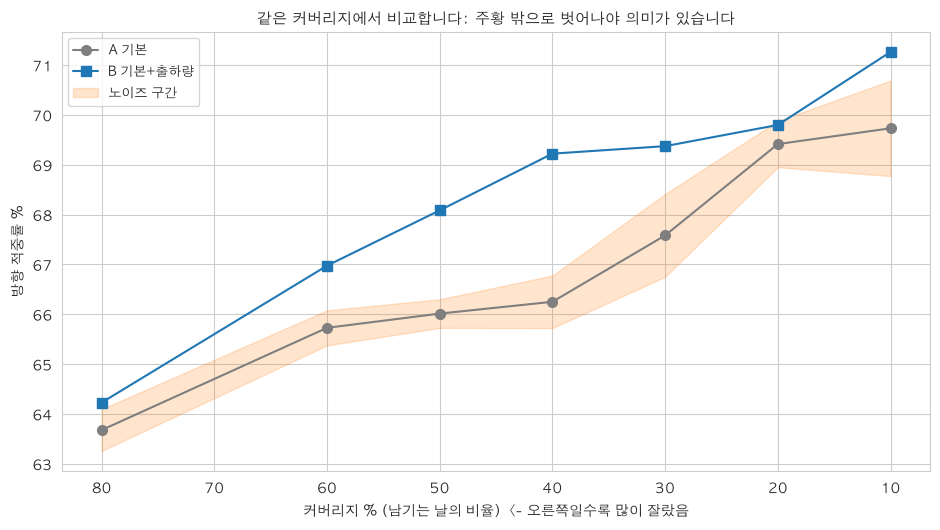

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
x = 실마리1["커버리지 %"]
ax.plot(x, 실마리1["A 기본 적중률 %"], "o-", ms=7, color="tab:gray", label="A 기본")
ax.plot(x, 실마리1["B 출하량 적중률 %"], "s-", ms=7, color="tab:blue",
        label="B 기본+출하량")
ax.fill_between(x, 실마리1["A 기본 적중률 %"] - 실마리1["노이즈 폭 %p"] / 2,
                실마리1["A 기본 적중률 %"] + 실마리1["노이즈 폭 %p"] / 2,
                color="tab:orange", alpha=0.2, label="노이즈 구간")
ax.invert_xaxis()
ax.set_xlabel("커버리지 % (남기는 날의 비율)  <- 오른쪽일수록 많이 잘랐음")
ax.set_ylabel("방향 적중률 %")
ax.set_title("같은 커버리지에서 비교합니다: 주황 밖으로 벗어나야 의미가 있습니다",
             fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. 실마리 ② C 방식 (18번)

18번에서 품목별 개별 모델(C)은 적중률이 가장 낮았는데(64.74%) **총액으로는 가장
많이 벌었습니다**(44.0만 원 vs A 33.9만 원). `item_code` 가 없어 확률이 0.5 에서
더 멀리 퍼지고, 그래서 **확신 커버리지가 73.07% 로 A(36.92%)의 두 배**였습니다.

커버리지가 두 배 차이 나는 비교는 성립하지 않습니다. 맞춰서 다시 잽니다.
**중간지대 4품목**입니다.

In [4]:
중간지대 = ["상추", "얼갈이배추", "풋고추", "배추"]
all_items = sorted(raw.item.unique())

d19 = 가격피처(raw, all_items).dropna(subset=["y", "미래가격"]).reset_index(drop=True)
d4 = 가격피처(raw[raw.item.isin(중간지대)], 중간지대) \
     .dropna(subset=["y", "미래가격"]).reset_index(drop=True)

t0 = time.time()
r_A = 돌리기(d19, PRICE + ["item_code"], 평가품목=중간지대)
parts = [돌리기(d4[d4.item == it], PRICE, 평가품목=[it]) for it in 중간지대]
r_C = pd.concat(parts).reset_index(drop=True)

noise_rows = []
for seed in (0, 1, 2, 3, 4):
    rn = 돌리기(d19, PRICE + ["item_code"], 평가품목=중간지대, noise=4, seed=seed)
    for cov in COVS:
        noise_rows.append({"seed": seed, "커버리지": cov, **커버리지컷(rn, cov)})
nz2 = pd.DataFrame(noise_rows)
floor2 = nz2.groupby("커버리지")["적중률 %"].agg(lambda s: s.max() - s.min())
floor2h = nz2.groupby("커버리지")["창고비 한도 %"].agg(lambda s: s.max() - s.min())

rows = []
for cov in COVS:
    a, c = 커버리지컷(r_A, cov), 커버리지컷(r_C, cov)
    rows.append({
        "커버리지 %": cov * 100,
        "A 적중률 %": a["적중률 %"], "C 적중률 %": c["적중률 %"],
        "적중률 차이 %p": c["적중률 %"] - a["적중률 %"],
        "노이즈 %p": floor2[cov],
        "A 창고비 한도 %": a["창고비 한도 %"], "C 창고비 한도 %": c["창고비 한도 %"],
        "한도 차이 %p": c["창고비 한도 %"] - a["창고비 한도 %"],
        "한도 노이즈 %p": floor2h[cov],
    })
실마리2 = pd.DataFrame(rows)
display(실마리2.round(2))
print(f"({time.time()-t0:.0f}초)")

,커버리지 %,A 적중률 %,C 적중률 %,적중률 차이 %p,노이즈 %p,A 창고비 한도 %,C 창고비 한도 %,한도 차이 %p,한도 노이즈 %p
0,80.0,69.17,68.88,-0.29,0.39,9.95,10.18,0.23,0.22
1,60.0,72.49,72.68,0.19,0.29,11.72,12.53,0.81,0.45
2,50.0,74.57,74.80,0.23,0.75,13.63,14.06,0.42,0.67
3,40.0,77.75,76.74,-1.01,0.72,15.91,15.14,-0.77,1.23
4,30.0,77.99,77.61,-0.38,1.05,16.00,16.61,0.61,1.09
5,20.0,79.05,77.91,-1.15,0.72,17.02,17.26,0.24,1.20
6,10.0,79.94,80.80,0.86,1.72,18.20,21.34,3.13,0.81


(99초)


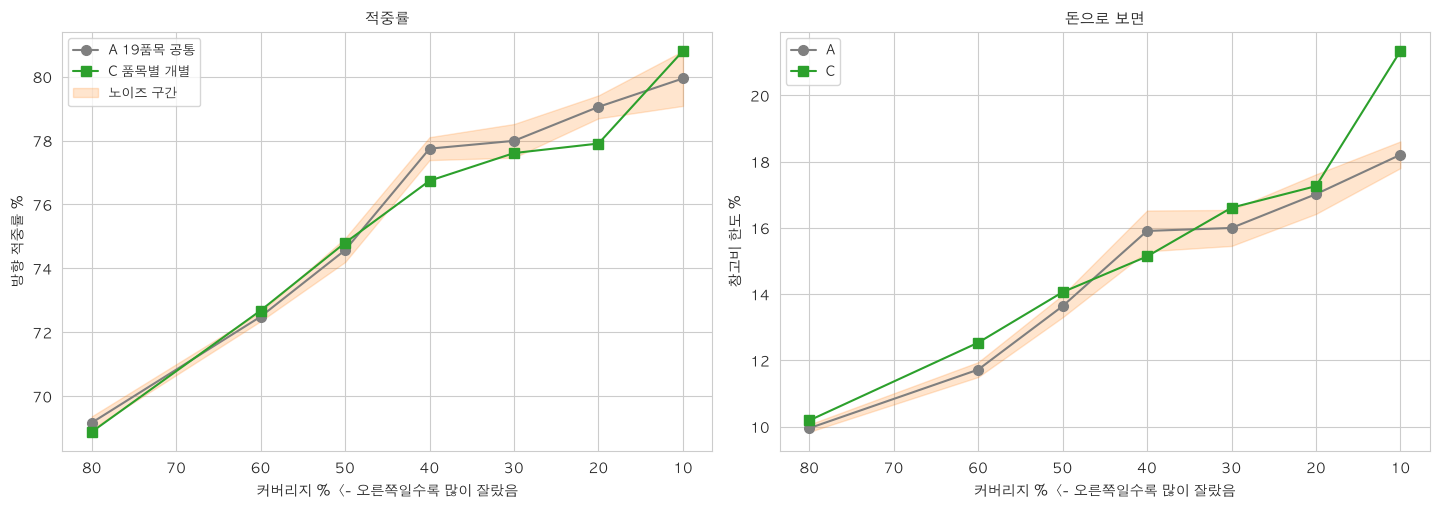

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
x = 실마리2["커버리지 %"]

ax = axes[0]
ax.plot(x, 실마리2["A 적중률 %"], "o-", ms=7, color="tab:gray", label="A 19품목 공통")
ax.plot(x, 실마리2["C 적중률 %"], "s-", ms=7, color="tab:green", label="C 품목별 개별")
ax.fill_between(x, 실마리2["A 적중률 %"] - 실마리2["노이즈 %p"] / 2,
                실마리2["A 적중률 %"] + 실마리2["노이즈 %p"] / 2,
                color="tab:orange", alpha=0.2, label="노이즈 구간")
ax.invert_xaxis()
ax.set_xlabel("커버리지 %  <- 오른쪽일수록 많이 잘랐음")
ax.set_ylabel("방향 적중률 %")
ax.set_title("적중률", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(x, 실마리2["A 창고비 한도 %"], "o-", ms=7, color="tab:gray", label="A")
ax.plot(x, 실마리2["C 창고비 한도 %"], "s-", ms=7, color="tab:green", label="C")
ax.fill_between(x, 실마리2["A 창고비 한도 %"] - 실마리2["한도 노이즈 %p"] / 2,
                실마리2["A 창고비 한도 %"] + 실마리2["한도 노이즈 %p"] / 2,
                color="tab:orange", alpha=0.2)
ax.invert_xaxis()
ax.set_xlabel("커버리지 %  <- 오른쪽일수록 많이 잘랐음")
ax.set_ylabel("창고비 한도 %")
ax.set_title("돈으로 보면", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. 모델 트랙 마무리

### 한 줄 요약

**①은 살아났고 ②는 죽었습니다.** 출하량은 **어느 날을 믿을지 고르는 데** 값을
합니다. C 방식의 우위는 **커버리지 차이가 만든 착시**였습니다.

### 실마리 ① 출하량: 부분 확인 — 16번을 정정합니다

| 커버리지 | A 기본 | B 출하량 | 차이 | 노이즈 | 판정 |
|---|---|---|---|---|---|
| 80% | 63.68% | 64.23% | +0.55%p | 0.84 | 노이즈 이내 |
| 60% | 65.73% | 66.98% | **+1.25%p** | 0.70 | **넘김** |
| 50% | 66.01% | 68.09% | **+2.07%p** | 0.58 | **넘김** |
| **40%** | 66.25% | 69.22% | **+2.97%p** | 1.05 | **넘김** |
| 30% | 67.58% | 69.37% | **+1.79%p** | 1.66 | **넘김** |
| 20% | 69.42% | 69.80% | +0.38%p | 0.93 | 노이즈 이내 |
| 10% | 69.73% | 71.26% | +1.53%p | 1.92 | 노이즈 이내 |

**16번의 결론은 절반만 맞았습니다.**

- 맞은 부분: **커버리지 80%**(사실상 전량)에서는 여전히 노이즈 이내입니다.
  "출하량은 전체 예측에 값을 안 한다"는 유지됩니다.
- **틀린 부분**: 커버리지 30~60% 구간에서는 노이즈를 뚜렷이 넘습니다.
  **출하량은 예측을 더 잘하게 만드는 게 아니라, 어느 날을 믿을지 더 잘 고르게
  합니다.**

**하필 운영 지점입니다.** 17번에서 채택한 확신도 0.20 이 커버리지 32% 근처인데,
차이가 가장 큰 구간(30~50%)이 정확히 거기입니다.

16번이 이걸 못 본 이유는 **전체 적중률 하나로만 판정**했기 때문입니다. 교훈 4가
또 걸렸습니다: 무엇을 재느냐에 따라 판정이 갈립니다.

**⚠️ 다음 할 일이 하나 되살아납니다.** 신규 13품목에 datago 출하량 매핑을 붙이는
백필(보류 중)의 근거가 생겼습니다. 다만 기상은 별개입니다: 16번에서 기상은
전 구간 악화였고 여기서 다시 재지 않았습니다.

**한계**: 6품목뿐이고, 20%·10% 에서는 다시 노이즈 이내로 들어갑니다. 표본이
줄어 노이즈가 넓어진 탓으로 보이지만, **효과가 단조롭지 않다는 점은 남습니다.**

### 실마리 ② C 방식: 반증 — 18번의 교차점을 취소합니다

| 커버리지 | 적중률 차이(C−A) | 노이즈 | 창고비 한도 차이 | 노이즈 |
|---|---|---|---|---|
| 80% | -0.29%p | 0.39 | +0.23%p | 0.22 |
| 60% | +0.19%p | 0.29 | +0.81%p | 0.45 |
| 50% | +0.23%p | 0.75 | +0.42%p | 0.67 |
| 40% | **-1.01%p** | 0.72 | -0.77%p | 1.23 |
| 30% | -0.38%p | 1.05 | +0.61%p | 1.09 |
| 20% | **-1.15%p** | 0.72 | +0.24%p | 1.20 |
| 10% | +0.86%p | 1.72 | **+3.13%p** | 0.81 |

**일관된 우열이 없습니다.** 적중률은 두 지점에서 C 가 지고, 창고비 한도는 세
지점에서 C 가 이깁니다. 나머지는 전부 노이즈 이내입니다. 부호가 커버리지마다
뒤집히는 건 **차이가 없다는 뜻**으로 읽는 게 맞습니다.

**18번의 "C 가 총액으로 더 번다"는 커버리지 차이였습니다.** C 는 `item_code` 가
없어 확률이 넓게 퍼져 저절로 73% 를 덮었고, A 는 37% 만 덮은 채로 비교됐습니다.
**A 도 임계값을 낮추면 73% 를 덮습니다.** 그렇게 맞춰 놓으면 C 가 주는 게 없습니다.

**따라서 18번의 "창고비 5.48% 에서 A 와 C 가 갈린다"는 취소합니다.** 서로 다른
커버리지를 비교해 나온 숫자라 실재하는 갈림길이 아닙니다. 커버리지를 정하는
문제이지 모델 구조를 고르는 문제가 아니었습니다.

### 모델 트랙을 닫습니다

15~21번에서 시도한 것과 결과입니다.

| 시도 | 결과 |
|---|---|
| 확신도로 날 고르기 (15) | **성공.** 62.8 → 72.1% |
| 출하량·기상 추가 (16) | 전체로는 무효 → **21번에서 부분 정정** |
| 확신하는 날의 쏠림 (17) | 쏠리지 않음. 운영 지점 0.20 확정 |
| 전용·개별 모델 (18) | 실패. 19품목 공통이 최선 |
| 정체 품목 제외 (19) | 대상에서만 제외. 창고비 한도 10.12 → 13.25% |
| 사는 쪽 (20) | 비슷하나 파는 쪽으로 확정 |
| 커버리지 맞춰 재기 (21) | 출하량 되살아남, C 방식 취소 |

**모델 구조·하이퍼파라미터·피처 조합으로 더 짜낼 것은 없습니다.** 남은 여지는
둘뿐입니다: **신규 13품목 출하량 매핑**(위 ①)과 **모델 밖 정보**(창고비·등급
하락·감모).

### 다음

1. **16·18번에 정정 주의를 답니다**(지침 12절: 앞 결론이 뒤집히면 지우지 않고
   주의를 단다).
2. **신규 13품목 datago 출하량 백필**의 우선순위를 올립니다. 기상은 제외합니다.
3. **통계·인과 트랙으로 넘어갑니다.** 예측은 여기서 닫고, 아직 한 번도 안 쓴
   내부 데이터(농협 계약재배 등)로 EDA 부터 다시 시작합니다.